
# Ontario Daily Weather (2017–2025) from NASA POWER

### What this notebook does:
 1) Loads Ontario boundary (Natural Earth Admin-1).
 2) Generates a systematic grid of sample points inside Ontario.
 3) Pulls NASA POWER Daily data for each point (SB community, fallback AG).
 4) Aggregates to a single Ontario daily series (mean across points).
 5) Saves ontario_daily_power_2017_2025.csv locally.

In [1]:
# Install (only if needed)
# !pip -q install geopandas shapely pyogrio fiona

In [2]:
import os
import time
import math
import zipfile
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed

import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

### 1. API Request Configuration

In [3]:
# Output file
OUTPUT_CSV = "../data/ontario_daily_weather_2017_2025.csv"

# Date range
START = "20170101"
END   = "20251231"

# POWER API base
POWER_BASE = "https://power.larc.nasa.gov/api/temporal/daily/point"

# Parameters (added RH2M, T2MDEW)
PARAMS = [
    "T2M", "T2M_MAX", "T2M_MIN",          # temperature
    "RH2M", "T2MDEW",                     # humidity + dew point (added)
    "PRECTOTCORR",                        # total precip (bias-corrected)
    "PRECSNO",                            # snow precip (water equivalent)
    "SNODP",                              # snow depth
    "ALLSKY_SFC_SW_DWN",                  # solar
    "CLOUD_AMT",                          # cloud
    "WS10M",                              # wind speed
]

# Time standard: UTC
TIME_STANDARD = "UTC"

# Sampling density (bigger step => fewer points => faster)
GRID_STEP_DEGREES = 2.0

# Concurrency
MAX_WORKERS = 8

# Polite pacing between requests (seconds)
REQUEST_DELAY = 0.15

# Request timeout
TIMEOUT = 60

# Community preference + fallback
COMMUNITY_PRIMARY = "SB"
COMMUNITY_FALLBACK = "AG"

### 2. Get Ontario Data

#### 2.1. Download Ontario boundary

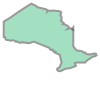

In [4]:
NE_URL = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"

resp = requests.get(NE_URL, timeout=TIMEOUT)
resp.raise_for_status()

z = zipfile.ZipFile(BytesIO(resp.content))
extract_dir = "ne_admin1"
os.makedirs(extract_dir, exist_ok=True)
z.extractall(extract_dir)

# Find the shapefile
shp_path = None
for fn in os.listdir(extract_dir):
    if fn.endswith(".shp"):
        shp_path = os.path.join(extract_dir, fn)
        break

if shp_path is None:
    raise FileNotFoundError("Could not find .shp in Natural Earth zip.")

gdf = gpd.read_file(shp_path)

# Ontario row: country Canada + name Ontario
ontario = gdf[(gdf["adm0_a3"] == "CAN") & (gdf["name"] == "Ontario")].copy()

if ontario.empty:
    ontario = gdf[(gdf["adm0_a3"] == "CAN") & (gdf["name"].str.contains("Ontario", case=False, na=False))].copy()

if ontario.empty:
    raise ValueError("Ontario polygon not found in Natural Earth admin-1 dataset.")

ontario = ontario.to_crs("EPSG:4326")  # ensure lat/lon
ont_poly = ontario.geometry.iloc[0]
ont_poly

#### 2.2. Create a systematic grid of sample points inside Ontario

In [5]:
minx, miny, maxx, maxy = ont_poly.bounds  # lon/lat bounds

lons = np.arange(math.floor(minx), math.ceil(maxx) + 1e-9, GRID_STEP_DEGREES)
lats = np.arange(math.floor(miny), math.ceil(maxy) + 1e-9, GRID_STEP_DEGREES)

points = []
for lat in lats:
    for lon in lons:
        p = Point(lon, lat)
        if ont_poly.contains(p):
            points.append((lat, lon))

print(f"Ontario sampling points inside polygon: {len(points)}")
points[:10]

Ontario sampling points inside polygon: 35


[(43.0, -82.0),
 (43.0, -80.0),
 (45.0, -82.0),
 (45.0, -80.0),
 (45.0, -78.0),
 (45.0, -76.0),
 (47.0, -84.0),
 (47.0, -82.0),
 (47.0, -80.0),
 (49.0, -94.0)]

#### 2.3. Download data for all the points

In [6]:
# Helper function to download on sampling point

def build_url(lat, lon, community):
    params_str = ",".join(PARAMS)
    return (
        f"{POWER_BASE}"
        f"?parameters={params_str}"
        f"&community={community}"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={START}"
        f"&end={END}"
        f"&format=JSON"
        f"&time-standard={TIME_STANDARD}"
    )

def fetch_point(lat, lon, session=None, max_retries=3):
    sess = session or requests.Session()

    for community in [COMMUNITY_PRIMARY, COMMUNITY_FALLBACK]:
        url = build_url(lat, lon, community)
        last_err = None

        for attempt in range(max_retries):
            try:
                r = sess.get(url, timeout=TIMEOUT)
                if r.status_code != 200:
                    last_err = RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
                    time.sleep(0.6 * (attempt + 1))
                    continue

                js = r.json()

                if isinstance(js, dict) and ("errors" in js or ("messages" in js and "ERROR" in str(js["messages"]).upper())):
                    last_err = RuntimeError(f"API error for ({lat},{lon}) community={community}: {js.get('messages') or js.get('errors')}")
                    time.sleep(0.6 * (attempt + 1))
                    continue

                data = js["properties"]["parameter"]
                return (lat, lon, community, data)

            except Exception as e:
                last_err = e
                time.sleep(0.6 * (attempt + 1))

        fallback_err = last_err

    raise RuntimeError(f"Failed for point ({lat},{lon}). Last error: {fallback_err}")


In [7]:
# Download all points (concurrent), then aggregate to Ontario daily series

def point_to_dataframe(lat, lon, community, data_dict):
    df = pd.DataFrame({p: pd.Series(data_dict.get(p, {})) for p in PARAMS})
    df.index.name = "YYYYMMDD"
    df.reset_index(inplace=True)

    df["Date"] = pd.to_datetime(df["YYYYMMDD"], format="%Y%m%d", errors="coerce")
    df.drop(columns=["YYYYMMDD"], inplace=True)

    df["lat"] = lat
    df["lon"] = lon
    df["community"] = community

    for c in PARAMS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df

all_point_dfs = []
failed = []

sess = requests.Session()

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = []
    for (lat, lon) in points:
        time.sleep(REQUEST_DELAY)
        futures.append(ex.submit(fetch_point, lat, lon, sess))

    for fut in as_completed(futures):
        try:
            lat, lon, community, data = fut.result()
            all_point_dfs.append(point_to_dataframe(lat, lon, community, data))
        except Exception as e:
            failed.append(str(e))

print(f"Downloaded points: {len(all_point_dfs)} / {len(points)}")
print(f"Failed: {len(failed)}")
if failed[:3]:
    print("Sample failures:\n", "\n".join(failed[:3]))

Downloaded points: 35 / 35
Failed: 0


#### 2.4. Combine point-level data into Ontario daily (one row per day)

In [8]:
if not all_point_dfs:
    raise RuntimeError("No point data downloaded. Check failures above.")

df_all = pd.concat(all_point_dfs, ignore_index=True)

df_daily = (
    df_all
    .groupby("Date", as_index=False)[PARAMS]
    .mean()
    .sort_values("Date")
)

# Derived variables:
# - Rain estimate (mm/day): total precip minus snow precip (water-equivalent), floored at 0
df_daily["Rainfall_Est"] = (df_daily["PRECTOTCORR"] - df_daily["PRECSNO"]).clip(lower=0)

df_daily = df_daily.rename(columns={
    "T2M": "Temp_Mean",
    "T2M_MAX": "Temp_Max",
    "T2M_MIN": "Temp_Min",
    "RH2M": "Relative_Humidity",
    "T2MDEW": "Dew_Point",
    "PRECTOTCORR": "Precipitation",
    "PRECSNO": "Snowfall",
    "SNODP": "Snow_Depth",
    "ALLSKY_SFC_SW_DWN": "Solar_Level",
    "CLOUD_AMT": "Cloud_Amount",
    "WS10M": "Wind_Speed",
})

# Final column order
df_daily = df_daily[
    [
        "Date",
        "Temp_Mean", "Temp_Max", "Temp_Min",
        "Relative_Humidity", "Dew_Point",
        "Precipitation", "Snowfall", "Rainfall_Est",
        "Snow_Depth",
        "Solar_Level",
        "Cloud_Amount",
        "Wind_Speed",
    ]
]

### 3. Save CSV

In [9]:
df_daily.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV)

df_daily.head(10)

Saved: ../data/ontario_daily_weather_2017_2025.csv


,Date,Temp_Mean,Temp_Max,Temp_Min,Relative_Humidity,Dew_Point,Precipitation,Snowfall,Rainfall_Est,Snow_Depth,Solar_Level,Cloud_Amount,Wind_Speed
0,2017-01-01,-14.451714,-10.260000,-18.959143,96.460571,-15.137143,0.830571,0.623714,0.206857,27.943429,37.785429,70.650000,3.232571
1,2017-01-02,-14.757429,-11.150286,-18.173429,96.258857,-15.437143,0.245143,0.357429,0.000000,27.847429,43.555143,54.770000,2.695714
2,2017-01-03,-14.472571,-12.228000,-16.879429,98.464286,-14.848286,3.591143,4.227714,0.000000,28.198286,22.740000,84.115143,2.567429
3,2017-01-04,-17.178286,-13.561429,-20.994571,97.007143,-17.664571,3.890286,3.968857,0.000000,29.862000,27.415429,87.992286,4.123714
4,2017-01-05,-20.465429,-18.203714,-22.366000,96.433143,-20.901429,1.042286,1.261143,0.000000,30.585429,36.765143,81.910000,4.585143
5,2017-01-06,-21.669429,-18.196286,-25.198571,96.632857,-22.091143,0.320000,0.583143,0.000000,30.488857,45.493429,66.081143,3.091429
6,2017-01-07,-21.636571,-18.110286,-25.122857,96.728286,-22.078571,0.350571,0.578857,0.000000,30.339714,48.266000,55.033143,2.902857
7,2017-01-08,-21.889714,-17.248286,-25.827714,97.354286,-22.232286,0.555429,0.720857,0.000000,30.224857,48.224286,61.967143,3.212286
8,2017-01-09,-18.555714,-13.939714,-23.690286,97.338857,-19.057429,1.348857,1.317714,0.031143,30.560857,44.469714,71.560857,3.241714
9,2017-01-10,-14.168571,-8.915714,-19.479143,97.870286,-14.662857,4.629143,6.314571,0.000000,31.156857,21.517143,91.910000,3.521143
